# Building an agent

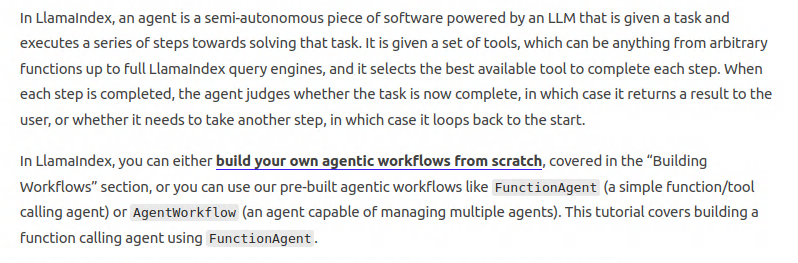

<b>Q:</b> What are the differences between FunctionAgent, ReActAgent and RouterEngine

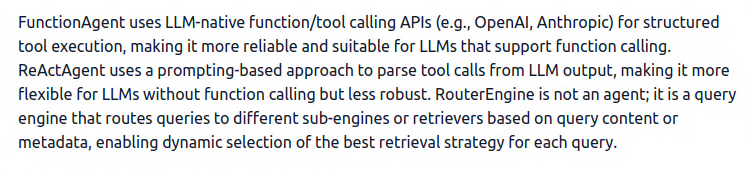

In [4]:
# 1.0 Call libraries
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.core import Settings
# 1.0.1
from llama_index.core.agent.workflow import FunctionAgent
from llama_index.core.tools import FunctionTool

In [15]:
# 1.1 Configure the llm
llm = Ollama(model="llama3.2:3b-instruct-q8_0",
             request_timeout=120.0,
             temperature = 0.9
            )

Settings.llm = llm

# 1.2 Global Embedding Model
Settings.embed_model = OllamaEmbedding(
                                       model_name="nomic-embed-text"
                                      )

Simple FunctionAgent

In [17]:

def add(a: int, b: int) -> int:
    return a + b

agent = FunctionAgent(
    tools=[FunctionTool.from_defaults(add)],
    llm=llm,
)

handler = agent.run("What is 2 + 5")
response = await handler
print(response)

The result of the calculation is 7.


Simple ReAct agent

In [23]:
from llama_index.core.agent.workflow import ReActAgent
from llama_index.core.tools import FunctionTool

def add(a: int, b: int) -> int:
    return a + b

llm = Ollama(model="llama3.1",
             request_timeout=120.0,
             temperature = 0.9
            )


response = await agent.run("What is 2 + 5?", verbose = True)
print(response)


The answer is 7.


## Agent Architecture

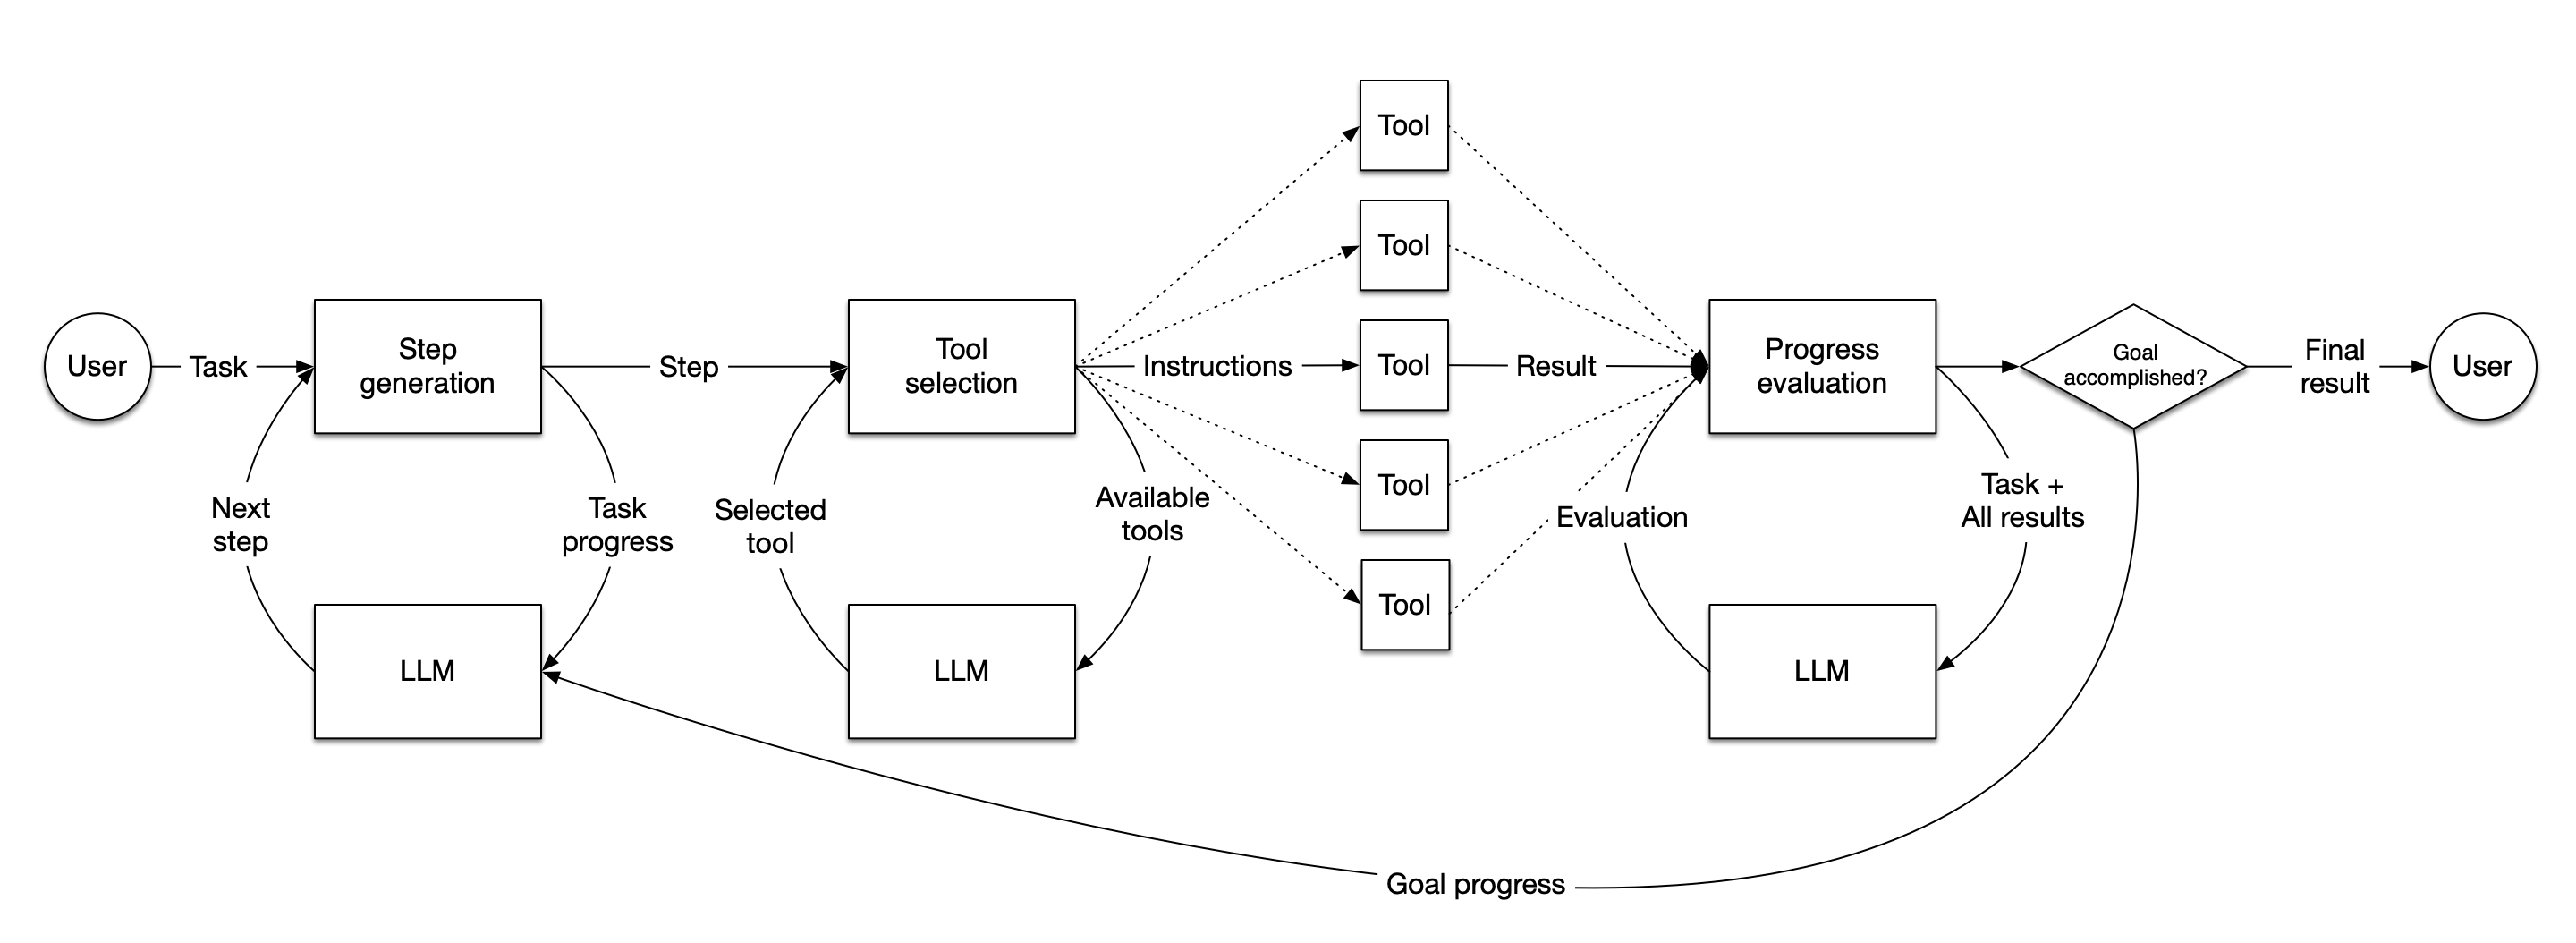

For this simple example we’ll be creating two tools: one that knows how to multiply numbers together, and one that knows how to add them.

In [25]:
# 1.1 Configure the llm
llm = Ollama(model="llama3.2:3b-instruct-q8_0",
             request_timeout=120.0,
             temperature = 0.9
            )

In [18]:
def multiply(a: float, b: float) -> float:
    """Multiply two numbers and returns the product"""
    return a * b


def add(a: float, b: float) -> float:
    """Add two numbers and returns the sum"""
    return a + b

As you can see, these are regular Python functions. When deciding what tool to use, your agent will use the tool’s name, parameters, and docstring to determine what the tool does and whether it’s appropriate for the task at hand. So it’s important to make sure the docstrings are descriptive and helpful. It will also use the type hints to determine the expected parameters and return type.

## Initialize the agent

Now we create our agent. It needs an array of tools, an LLM, and a system prompt to tell it what kind of agent to be. Your system prompt would usually be more detailed than this!

In [26]:
workflow = FunctionAgent(
                            tools=[multiply, add],
                            llm=llm,
                            system_prompt="You are an agent that can perform basic mathematical operations using tools.",
                        )

In [27]:
response = await workflow.run(user_msg="What is 20+(2*4)?")
print(response)

The result of the expression 20 + (2 * 4) is 220.


In [ ]:
############## Done ############

In [28]:
!pip install llama-index-tools-yahoo-finance

  Attempting uninstall: yfinance
    Found existing installation: yfinance 1.2.0
    Uninstalling yfinance-1.2.0:
      Successfully uninstalled yfinance-1.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [llama-index-tools-yahoo-finance]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [29]:
from llama_index.tools.yahoo_finance import YahooFinanceToolSpec

In [33]:
finance_tools = YahooFinanceToolSpec().to_tool_list()
finance_tools

In [38]:
finance_tools.extend([multiply, add])

In [39]:
workflow = FunctionAgent(
    name="Agent",
    description="Useful for performing financial operations.",
    llm=llm,
    tools=finance_tools,
    system_prompt="You are a helpful assistant.",
)


async def main():
    response = await workflow.run(
        user_msg="What's the current stock price of NVIDIA?"
    )
    print(response)

In [41]:
await main()

The current stock price of NVIDIA is $201.68.
